### Importing Libraries

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

### Load Dataset

In [24]:
data1 = pd.read_csv("../DataSet/Crop_recommendation.csv")

### Shape of the dataset

In [26]:
print("Shape:", data1.shape)

Shape: (2200, 8)


In [27]:
data1.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


### Encode Target

In [29]:
le = LabelEncoder()
data1['label'] = le.fit_transform(data1['label'])

print("Classes:", list(le.classes_))

Classes: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


### Split Features and Target

In [36]:
X = data1.drop('label', axis=1)
y = data1['label']

print("Features:", list(X.columns))
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X shape: (2200, 7)
y shape: (2200,)


### All Models

In [40]:
models = {
    'Random Forest':       RandomForestClassifier(criterion='log_loss', random_state=42),
    'Decision Tree':       DecisionTreeClassifier(criterion='entropy', random_state=42),
    'XGBoost':             XGBClassifier(reg_lambda=1, random_state=42, verbosity=0),
    'SVM':                 SVC(gamma=1, random_state=42),
    'Logistic Regression': LogisticRegression(C=100, max_iter=1000, random_state=42),
    'KNN':                 KNeighborsClassifier(metric='minkowski', p=3)
}

### Run 5-Fold Stratified Cross Validation
* Note: Pipeline wraps scaler + model together
* This means scaler is fit only on training folds each time
* No data leakage across folds

In [45]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  model)
    ])

    scores = cross_validate(
        pipeline, X, y,
        cv=cv,
        scoring=['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted'],
        return_train_score=True
    )

    cv_results.append({
        'Model':            name,
        'Train Acc Mean':   round(scores['train_accuracy'].mean(), 4),
        'Train Acc Std':    round(scores['train_accuracy'].std(),  4),
        'Test Acc Mean':    round(scores['test_accuracy'].mean(),  4),
        'Test Acc Std':     round(scores['test_accuracy'].std(),   4),
        'F1 Mean':          round(scores['test_f1_weighted'].mean(), 4),
        'F1 Std':           round(scores['test_f1_weighted'].std(),  4),
    })

    print(f"{name:25s} | Test Acc: {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")

Random Forest             | Test Acc: 0.9950 ± 0.0030
Decision Tree             | Test Acc: 0.9850 ± 0.0037
XGBoost                   | Test Acc: 0.9936 ± 0.0039
SVM                       | Test Acc: 0.9873 ± 0.0037
Logistic Regression       | Test Acc: 0.9809 ± 0.0037
KNN                       | Test Acc: 0.9709 ± 0.0062


# Results

In [48]:
cv_df = (pd.DataFrame(cv_results)
           .sort_values('Test Acc Mean', ascending=False)
           .reset_index(drop=True))

cv_df.index += 1  # rank starts from 1

print("\n5-Fold Stratified Cross-Validation Results")
print("=" * 80)
print(cv_df.to_string())
print("=" * 80)
print(f"\nBest Model : {cv_df.iloc[0]['Model']}")
print(f"Test Acc   : {cv_df.iloc[0]['Test Acc Mean']} ± {cv_df.iloc[0]['Test Acc Std']}")


5-Fold Stratified Cross-Validation Results
                 Model  Train Acc Mean  Train Acc Std  Test Acc Mean  Test Acc Std  F1 Mean  F1 Std
1        Random Forest          1.0000         0.0000         0.9950        0.0030   0.9950  0.0030
2              XGBoost          1.0000         0.0000         0.9936        0.0039   0.9936  0.0039
3                  SVM          0.9938         0.0004         0.9873        0.0037   0.9872  0.0037
4        Decision Tree          1.0000         0.0000         0.9850        0.0037   0.9849  0.0037
5  Logistic Regression          0.9920         0.0008         0.9809        0.0037   0.9808  0.0038
6                  KNN          0.9836         0.0025         0.9709        0.0062   0.9708  0.0062

Best Model : Random Forest
Test Acc   : 0.995 ± 0.003


### Bar Chart With Error Bars

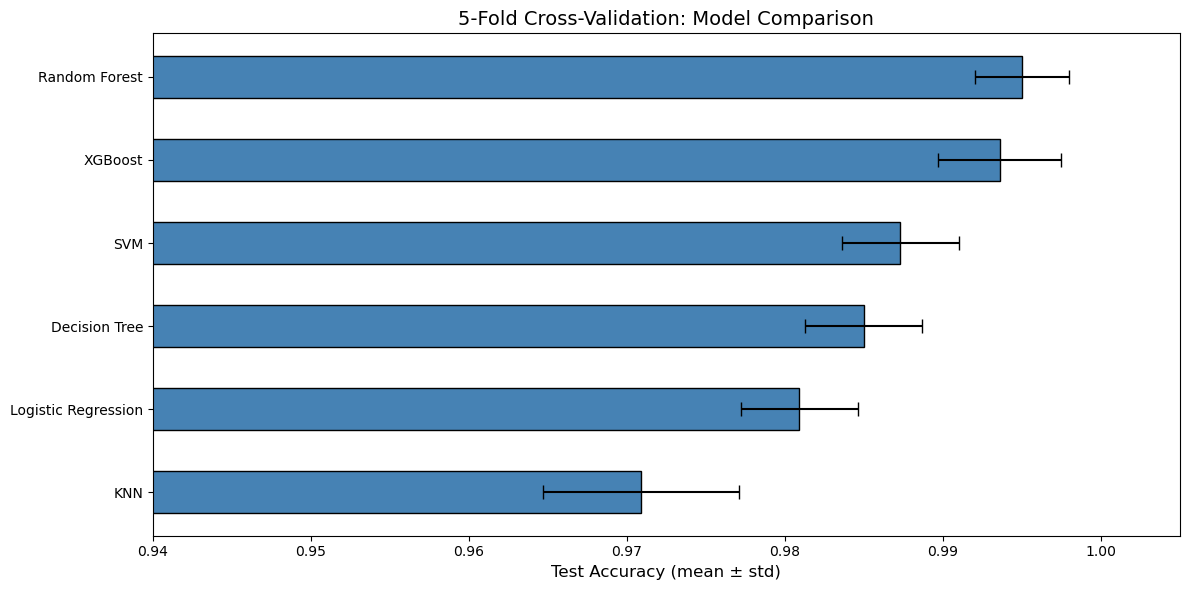

In [51]:
plt.figure(figsize=(12, 6))

plt.barh(
    cv_df['Model'],
    cv_df['Test Acc Mean'],
    xerr=cv_df['Test Acc Std'],
    color='steelblue',
    edgecolor='black',
    capsize=5,
    height=0.5
)

plt.xlabel("Test Accuracy (mean ± std)", fontsize=12)
plt.title("5-Fold Cross-Validation: Model Comparison", fontsize=14)
plt.xlim(0.94, 1.005)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()